# Recorded Results: BLIP on Flickr8k

This notebook reads the exported experiment artifacts. It displays recorded test scores, training curves, and image-caption examples without loading model weights or rerunning training. The training pipeline is in `train_blip.ipynb`.

In [1]:
import csv
import json
from html import escape
from pathlib import Path
from IPython.display import HTML, Image, Markdown, display

ROOT = Path.cwd()
if not (ROOT / "results").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "results").is_dir(), "Run this notebook from the repository or notebooks directory."
RESULTS = ROOT / "results"

with (RESULTS / "metrics_comparison.csv").open(newline="") as f:
    scores = list(csv.DictReader(f))
with (RESULTS / "training_history.csv").open(newline="") as f:
    history = list(csv.DictReader(f))
config = json.loads((ROOT / "config.json").read_text())
selection = json.loads((ROOT / "best_checkpoint_selection.json").read_text())
environment = json.loads((RESULTS / "environment.json").read_text())

def show_table(rows, columns, decimals=4):
    header = "".join(f"<th>{escape(key)}</th>" for key in columns)
    body = []
    for row in rows:
        values = []
        for key in columns:
            value = row[key]
            try:
                number = float(value)
                value = f"{number:.{decimals}f}" if not number.is_integer() else str(int(number))
            except (TypeError, ValueError):
                pass
            values.append(f"<td>{escape(str(value))}</td>")
        body.append("<tr>" + "".join(values) + "</tr>")
    display(HTML("<table><thead><tr>" + header + "</tr></thead><tbody>" + "".join(body) + "</tbody></table>"))

## Test scores

Both checkpoints use the same 1,000 test images and five reference captions per image. Scores use the lowercase word tokenizer documented in the training notebook. CIDEr is reported on its native implementation scale.

model,n_test_images,BLEU-1,BLEU-2,BLEU-3,BLEU-4,CIDEr,seconds_per_image
baseline,1000,0.6586,0.5047,0.3736,0.2741,0.7066,0.1504
fine_tuned,1000,0.7454,0.5896,0.4529,0.3387,1.0064,0.1510


BLEU-4 changed by **+0.0646** and CIDEr by **+0.2998**.

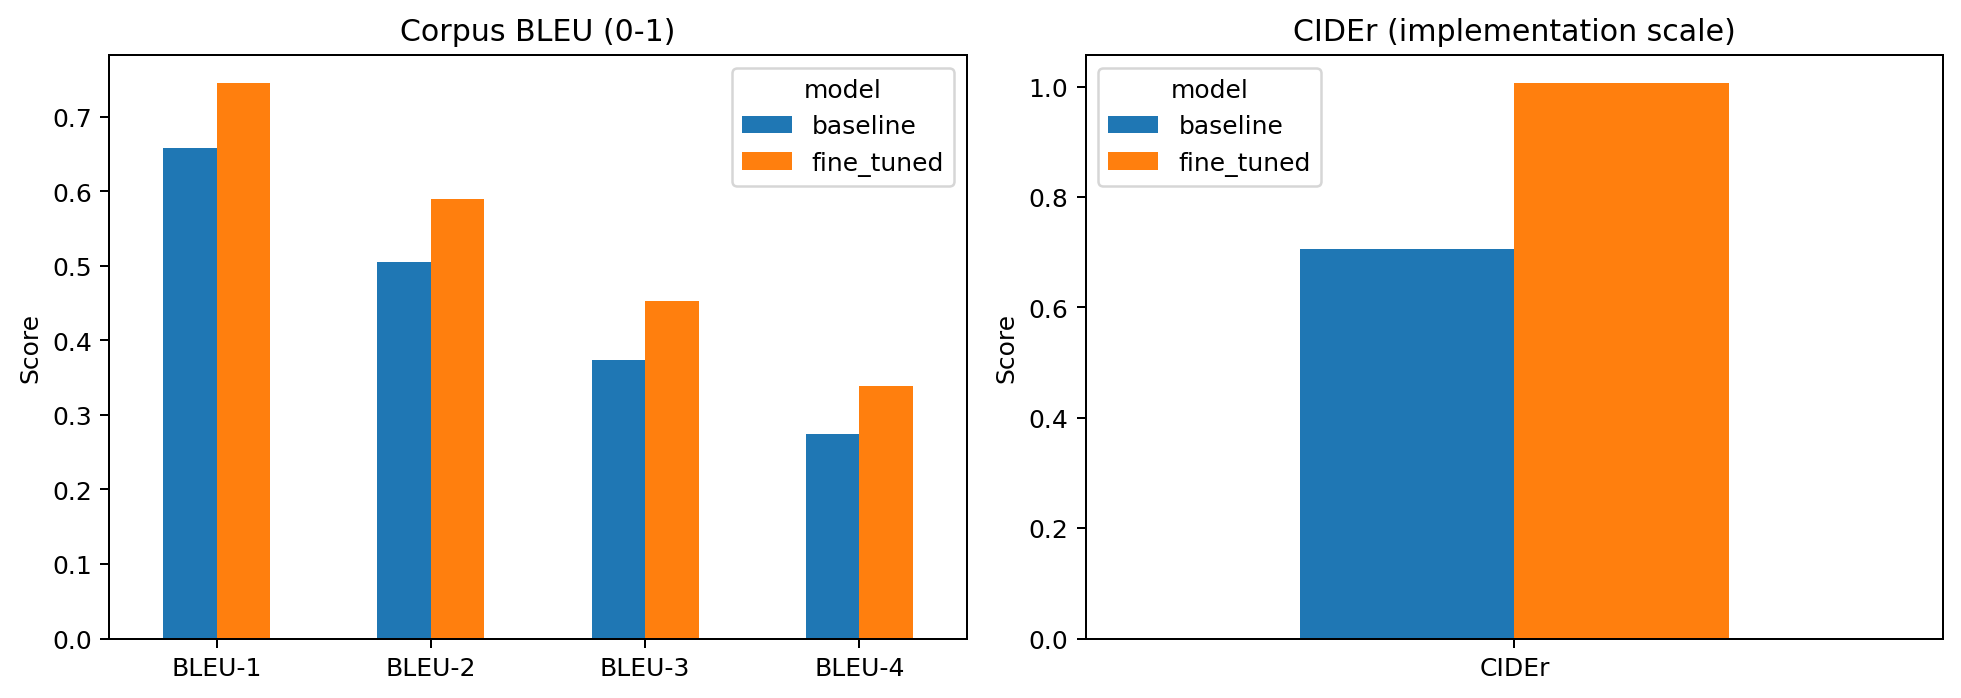

In [2]:
show_table(scores, ["model", "n_test_images", "BLEU-1", "BLEU-2", "BLEU-3", "BLEU-4", "CIDEr", "seconds_per_image"])
by_model = {row["model"]: row for row in scores}
bleu_delta = float(by_model["fine_tuned"]["BLEU-4"]) - float(by_model["baseline"]["BLEU-4"])
cider_delta = float(by_model["fine_tuned"]["CIDEr"]) - float(by_model["baseline"]["CIDEr"])
display(Markdown(f"BLEU-4 changed by **{bleu_delta:+.4f}** and CIDEr by **{cider_delta:+.4f}**."))
display(Image(filename=str(RESULTS / "metrics_comparison.png")))

## Training history

The checkpoint is selected by the lowest validation loss. Validation loss uses the first caption for each validation image, while test metrics use all five references.

epoch,train_loss,val_loss,epoch_seconds,peak_allocated_vram_gb
1,2.3283,1.9368,317.2806,3.4616
2,1.8974,1.8877,326.2502,3.4488
3,1.8521,1.8503,371.9892,3.4489
4,1.8207,1.8316,378.1943,3.4246
5,1.8042,1.8244,374.1243,3.4346


Selected epoch: 5
Selected validation loss: 1.8244
GPU: Tesla T4
Training and validation time: 29.5 minutes


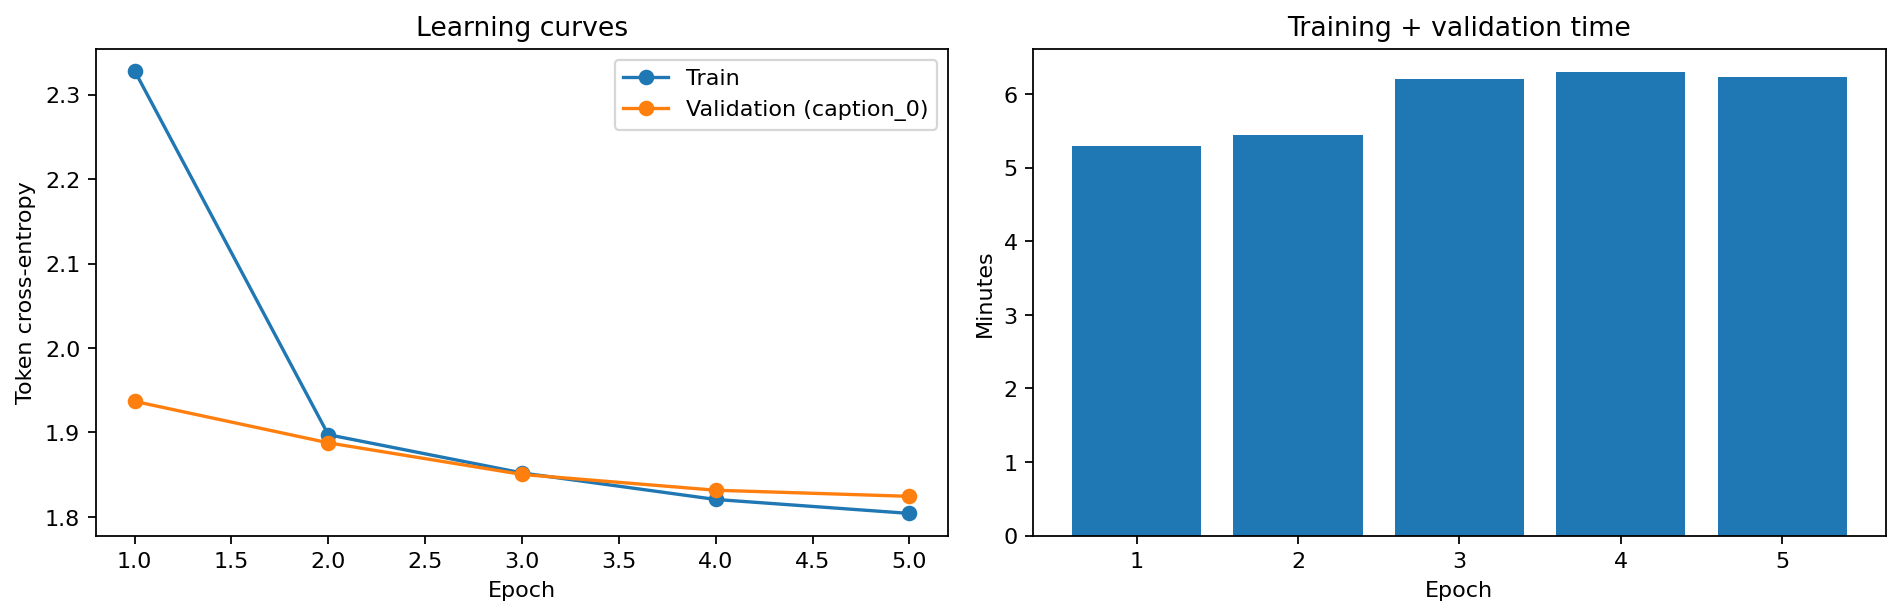

In [3]:
show_table(history, ["epoch", "train_loss", "val_loss", "epoch_seconds", "peak_allocated_vram_gb"])
print(f"Selected epoch: {selection['epoch']}")
print(f"Selected validation loss: {selection['validation_loss']:.4f}")
print(f"GPU: {environment['gpu']}")
print(f"Training and validation time: {sum(float(row['epoch_seconds']) for row in history) / 60:.1f} minutes")
display(Image(filename=str(RESULTS / "training_curves.png")))

## Example predictions

The examples below are the first three entries in the saved random-review sample. Their captions are read from the comparison CSV. The complete sample figure is available at `results/random_caption_examples.png`.

### Test image 640

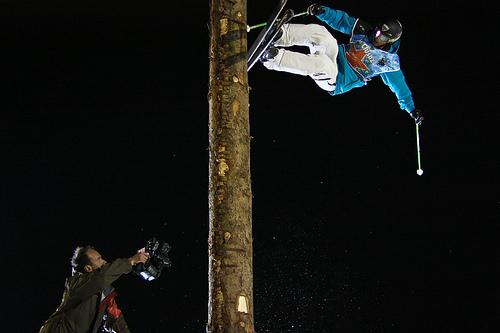

Reference: A camera man videotapes a skier climbing a tree stump . Baseline: snowboarder in the air Fine-tuned: a snowboarder jumps off a pole while another snowboarder watches.

### Test image 19

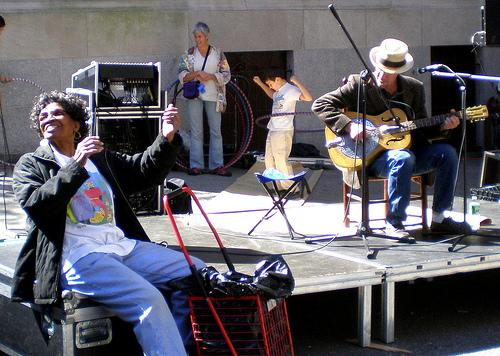

Reference: A guitarist plays while people play with hula-hoops in the background . Baseline: a group of people playing music on a stage Fine-tuned: a group of people are playing instruments and singing.

### Test image 272

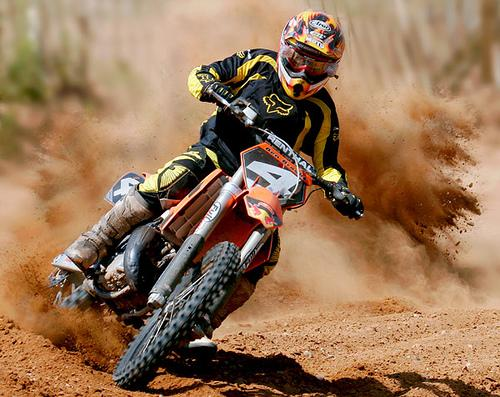

Reference: a dirt biker turns across the dirt . Baseline: a man riding a dirt bike on a dirt track Fine-tuned: a person on a dirt bike is riding on a dirt track.

In [4]:
with (RESULTS / "caption_comparison.csv").open(newline="") as f:
    predictions = {int(row["test_index"]): row for row in csv.DictReader(f)}
review_key = json.loads((RESULTS / "human_review_model_key.json").read_text())
for entry in review_key[:3]:
    index = int(entry["test_index"])
    row = predictions[index]
    display(Markdown(f"### Test image {index}"))
    display(Image(filename=str(RESULTS / "review_images" / f"test_{index:04d}.jpg"), width=500))
    display(HTML(
        f"<p><strong>Reference:</strong> {escape(row['reference_0'])}</p>"
        f"<p><strong>Baseline:</strong> {escape(row['baseline'])}</p>"
        f"<p><strong>Fine-tuned:</strong> {escape(row['fine_tuned'])}</p>"
    ))

## Evaluation scope

These artifacts record one run with seed 42. The exact-duplicate audit concerns Flickr8k splits; overlap with pretraining data has not been verified. The timing results measure batch throughput after warm-up, rather than single-request latency. The manual-review scoring fields remain unfilled, so no human-evaluation score is reported.